In [ ]:
# Fast Baseline Model for Protein-Protein Binding Affinity Prediction
# FINAL VERSION: Includes fix for JSON serialization of NumPy types.

import os
import sys
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import KFold, GroupKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import warnings
import pickle
import copy
from scipy.spatial.distance import squareform
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

# Imports for the sequence similarity split from PEFT script
from sklearn.cluster import AgglomerativeClustering

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🧬 Fast Baseline Model for Protein-Protein Binding Affinity Prediction")
print("⚡ Optimized with Pre-computed Embeddings")
print("🔧 MODIFIED: Consistent Training Logic & JSON Serialization Fix")
print("="*80)

In [ ]:

# ============================================================================
# 1. REPRODUCIBILITY SETUP
# ============================================================================
def setup_reproducibility(seed=42):
    """Setup complete reproducibility."""
    print(f"🔒 Setting up reproducibility with seed {seed}")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility setup complete")

setup_reproducibility(42)

In [ ]:

# ============================================================================
# 2. FAST EMBEDDING COMPUTATION
# ============================================================================
class FastEmbeddingExtractor:
    def __init__(self, model_name="facebook/esm2_t33_650M_UR50D", max_seq_len=1024, batch_size=16, device="auto"):
        self.model_name, self.max_seq_len, self.batch_size = model_name, max_seq_len, batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if device == "auto" else torch.device(device)
        print(f"🔧 Initializing FastEmbeddingExtractor on {self.device}")
        print("📥 Loading ESM-2 model...")
        self.model = AutoModel.from_pretrained(model_name).to(self.device).eval()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Identify the CLS token (usually <s> for ESM-2)
        self.cls_token = self.tokenizer.cls_token
        self.embedding_size = self.model.config.hidden_size
        self.embedding_cache = {}
        print(f"✅ Model loaded. Using CLS token: {self.cls_token}")

    def get_embeddings(self, sequences, use_cache=True, show_progress=True):
        if isinstance(sequences, str): sequences = [sequences]
        embeddings, to_compute, to_compute_indices = [], [], []

        for i, seq in enumerate(sequences):
            if use_cache and seq in self.embedding_cache:
                embeddings.append(self.embedding_cache[seq])
            else:
                embeddings.append(None)
                to_compute.append(seq)
                to_compute_indices.append(i)

        if to_compute:
            if show_progress: print(f"🧮 Computing {len(to_compute)} new embeddings with Double CLS...")
            pbar = tqdm(range(0, len(to_compute), self.batch_size), desc="Computing embeddings", disable=not show_progress)

            for start_idx in pbar:
                batch_raw = to_compute[start_idx : start_idx + self.batch_size]

                # --- MODIFICATION: Replace '|' with '<s><s>' ---
                batch_sequences = [s.replace('|', f"{self.cls_token}{self.cls_token}") for s in batch_raw]

                inputs = self.tokenizer(batch_sequences, padding=True, truncation=True, max_length=self.max_seq_len, return_tensors="pt")
                inputs = {k: v.to(self.device) for k, v in inputs.items()}

                with torch.no_grad():
                    outputs = self.model(**inputs)
                    # Use Mean Pooling over last_hidden_state (more robust for concatenated chains)
                    hidden_states = outputs.last_hidden_state
                    attention_mask = inputs['attention_mask']

                    mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
                    sum_embeddings = torch.sum(hidden_states * mask_expanded, 1)
                    sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
                    batch_embeddings = (sum_embeddings / sum_mask).cpu()

                if use_cache:
                    for j, seq in enumerate(batch_raw):
                        self.embedding_cache[seq] = batch_embeddings[j:j+1]

                for i, orig_idx in enumerate(to_compute_indices[start_idx : start_idx + self.batch_size]):
                    embeddings[orig_idx] = batch_embeddings[i:i+1]

        return torch.cat(embeddings, dim=0)

    def save_cache(self, cache_path):
        with open(cache_path, 'wb') as f: pickle.dump(self.embedding_cache, f)
        print(f"💾 Saved {len(self.embedding_cache)} cached embeddings to {cache_path}")

    def load_cache(self, cache_path):
        if os.path.exists(cache_path):
            with open(cache_path, 'rb') as f: self.embedding_cache = pickle.load(f)
            print(f"📥 Loaded {len(self.embedding_cache)} cached embeddings from {cache_path}")


In [ ]:


# ============================================================================
# 3. FAST BASELINE MODEL
# ============================================================================
class FastBaselinePPIModel(nn.Module):
    def __init__(self, embedding_size=1280, projected_size=256, projected_dropout=0.1, device="auto"):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if device == "auto" else torch.device(device)
        self.linear_projection = nn.Linear(2 * embedding_size, projected_size)
        self.dropout = nn.Dropout(projected_dropout)
        self.out = nn.Linear(projected_size, 1)
        self.loss_fn = nn.MSELoss()
        self.to(self.device)

    def forward(self, protein1_embeddings, protein2_embeddings, labels=None):
        concat_emb = torch.cat((protein1_embeddings.to(self.device), protein2_embeddings.to(self.device)), dim=1)
        proj_emb = F.relu(self.dropout(self.linear_projection(concat_emb)))
        logits = self.out(proj_emb).squeeze(-1)
        output = {"logits": logits}
        if labels is not None:
            output["loss"] = self.loss_fn(logits, labels.to(self.device))
        return output


In [ ]:

# ============================================================================
# 4. DATASET & METRICS
# ============================================================================
class FastPPIDataset(Dataset):
    def __init__(self, dataframe, protein1_embeddings, protein2_embeddings):
        self.data, self.p1_emb, self.p2_emb = dataframe.reset_index(drop=True), protein1_embeddings, protein2_embeddings
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        return {"p1_emb": self.p1_emb[idx], "p2_emb": self.p2_emb[idx], "label": float(self.data.iloc[idx]["Y"])}

def fast_collate_fn(batch):
    return {
        "protein1_embeddings": torch.stack([item["p1_emb"] for item in batch]),
        "protein2_embeddings": torch.stack([item["p2_emb"] for item in batch]),
        "labels": torch.tensor([item["label"] for item in batch], dtype=torch.float32)
    }

def calculate_metrics(predictions, labels):
    predictions, labels = np.array(predictions), np.array(labels)
    # Return NaN if there are not enough samples for correlation metrics
    if len(labels) < 2: return {"rmse": np.nan, "pearson": np.nan, "spearman": np.nan, "ci": np.nan}
    rmse = np.sqrt(mean_squared_error(labels, predictions))
    pearson_r, _ = pearsonr(predictions, labels)
    spearman_r, _ = spearmanr(predictions, labels)
    def ci(y_true, y_pred):
        n, concordant = len(y_true), 0
        total_pairs = 0
        for i in range(n):
            for j in range(i + 1, n):
                if y_true[i] != y_true[j]:
                    total_pairs += 1
                    if (y_true[i] > y_true[j] and y_pred[i] > y_pred[j]) or \
                       (y_true[i] < y_true[j] and y_pred[i] < y_pred[j]):
                        concordant += 1
        return concordant / total_pairs if total_pairs > 0 else 1.0
    return {"rmse": rmse, "pearson": pearson_r, "spearman": spearman_r, "ci": ci(labels, predictions)}


In [ ]:


# ============================================================================
# 5. TRAINING & EVALUATION LOOPS
# ============================================================================
def train_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        loss = model(**batch)["loss"]
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            all_preds.extend(model(**batch)["logits"].cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
    return all_preds, all_labels, calculate_metrics(all_preds, all_labels)

In [ ]:


# ============================================================================
# 6. DATA SPLITTING (EXACT REPLICATION)
# ============================================================================
def _get_sequence_similarity_splits(df, n_folds=5, seed=42):
    print("\n🧬 Performing k-mer/agglomerative sequence similarity splitting...")
    unique_sequences = sorted(list(set(df['Target'].tolist() + df['proteina'].tolist())))
    print(f"   Found {len(unique_sequences)} unique, sorted sequences.")

    def get_kmers(seq, k=3): return {seq[i:i+k] for i in range(len(seq) - k + 1)}
    kmer_sets = [get_kmers(s) for s in unique_sequences]
    sim_matrix = np.array([[len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0 for s2 in kmer_sets] for s1 in tqdm(kmer_sets, desc="Calculating similarities")])

    # MODIFIED: Use scipy for deterministic clustering (consistent with PEFT)
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import linkage, fcluster

    distance_matrix = 1.0 - sim_matrix
    distance_threshold = 1.0 - 0.3  # 0.7

    # Convert to condensed distance matrix
    condensed_dist = squareform(distance_matrix, checks=False)

    # Perform hierarchical clustering (DETERMINISTIC)
    Z = linkage(condensed_dist, method='average')

    # Cut dendrogram at distance threshold
    clusters = fcluster(Z, t=distance_threshold, criterion='distance')

    # Convert to 0-indexed (fcluster returns 1-indexed)
    clusters = clusters - 1
    seq_to_cluster = {seq: cid for seq, cid in zip(unique_sequences, clusters)}

    cluster_ids = np.unique(clusters)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    splits = []
    for train_cid_idx, test_cid_idx in kf.split(cluster_ids):
        test_c_set = set(cluster_ids[test_cid_idx])
        train_idx = df[df.apply(lambda r: seq_to_cluster[r['Target']] not in test_c_set and seq_to_cluster[r['proteina']] not in test_c_set, axis=1)].index
        test_idx = df.index.difference(train_idx)
        splits.append((train_idx.to_numpy(), test_idx.to_numpy()))
    return splits, df

def get_data_splits(df, split_method="random", n_folds=5, seed=42):
    print(f"🔄 Creating {split_method} splits with {n_folds} folds")
    if split_method == "random": return list(KFold(n_splits=n_folds, shuffle=True, random_state=seed).split(df)), df
    if split_method == "cold_target": return list(GroupKFold(n_splits=n_folds).split(df, groups=df["PDB"].factorize()[0])), df
    if split_method == "sequence_similarity": return _get_sequence_similarity_splits(df, n_folds, seed)
    raise ValueError(f"Unknown split method: {split_method}")

In [ ]:


# ============================================================================
# 7. MAIN CROSS-VALIDATION FUNCTION (WITH JSON FIX)
# ============================================================================
def json_converter(o):
    """Helper function to convert numpy types to native python types for JSON serialization."""
    if isinstance(o, np.generic):
        return o.item() # .item() converts numpy types to python native types
    raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")

def run_fast_cross_validation(df, split_method, config):
    print(f"\n⚡ Running {config['n_folds']}-fold CV with '{split_method}' split")
    output_dir = Path(config["output_dir"]); cache_dir = Path(config["cache_dir"])
    output_dir.mkdir(exist_ok=True, parents=True); cache_dir.mkdir(exist_ok=True, parents=True)

    splits, df_processed = get_data_splits(df, split_method, config['n_folds'], config['seed'])

    embedding_extractor = FastEmbeddingExtractor()
    cache_file = cache_dir / "embedding_cache.pkl"
    embedding_extractor.load_cache(cache_file)

    all_seqs = sorted(list(set(df_processed["Target"].tolist() + df_processed["proteina"].tolist())))
    unique_embs = embedding_extractor.get_embeddings(all_seqs)
    seq_to_emb = {seq: unique_embs[i:i+1] for i, seq in enumerate(all_seqs)}
    embedding_extractor.save_cache(cache_file)

    p1_embs = torch.cat([seq_to_emb[seq] for seq in df_processed["Target"]], dim=0)
    p2_embs = torch.cat([seq_to_emb[seq] for seq in df_processed["proteina"]], dim=0)

    cv_results, all_predictions, all_labels = [], [], []

    for fold, (train_idx, test_idx) in enumerate(splits):
        fold_num = fold + 1
        print(f"\n{'='*20} FOLD {fold_num}/{config['n_folds']} {'='*20}")
        print(f"   Split: Train={len(train_idx)}, Test={len(test_idx)}")

        train_loader = DataLoader(FastPPIDataset(df_processed.iloc[train_idx], p1_embs[train_idx], p2_embs[train_idx]),
                                  batch_size=config['batch_size'], shuffle=True, collate_fn=fast_collate_fn)
        test_loader = DataLoader(FastPPIDataset(df_processed.iloc[test_idx], p1_embs[test_idx], p2_embs[test_idx]),
                                 batch_size=config['batch_size']*2, shuffle=False, collate_fn=fast_collate_fn)

        model = FastBaselinePPIModel()
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])

        best_val_rmse, patience_counter, best_model_state = float('inf'), 0, None

        pbar = tqdm(range(config['epochs']), desc=f"Fold {fold_num} Training")
        for epoch in pbar:
            train_loss = train_epoch(model, train_loader, optimizer)
            
            # Evaluate on validation set
            _, _, val_metrics = evaluate_model(model, test_loader)
            current_val_rmse = val_metrics['rmse']
            
            pbar.set_postfix({
                "Train Loss": f"{train_loss:.4f}", 
                "Val RMSE": f"{current_val_rmse:.4f}"
            })

            # Save best model based on Validation RMSE (consistent with PEFT)
            if current_val_rmse < best_val_rmse:
                best_val_rmse = current_val_rmse
                patience_counter = 0
                best_model_state = copy.deepcopy(model.state_dict())
                # print(f"   -> New best model with Val RMSE: {best_val_rmse:.4f}")
            else:
                patience_counter += 1

            if patience_counter >= config['patience']:
                print(f"   ⏳ Early stopping at epoch {epoch+1}. Val RMSE has not improved for {config['patience']} epochs.")
                break

        if best_model_state: model.load_state_dict(best_model_state)

        preds, labels, metrics = evaluate_model(model, test_loader)
        cv_results.append(metrics); all_predictions.extend(preds); all_labels.extend(labels)
        print(f"   📊 Fold Results: " + ", ".join([f"{k.upper()}: {v:.4f}" for k, v in metrics.items()]))
        del model; torch.cuda.empty_cache()

    print(f"\n📈 CV Summary ({split_method})")
    summary_df = pd.DataFrame(cv_results)
    aggregate_metrics = {f"{key}_{stat}": summary_df[key].agg(stat) for key in summary_df.columns for stat in ['mean', 'std']}
    for key in summary_df.columns:
        print(f"   {key.upper()}: {aggregate_metrics[f'{key}_mean']:.4f} ± {aggregate_metrics[f'{key}_std']:.4f}")

    create_regression_plot(all_predictions, all_labels, aggregate_metrics, output_dir / f"regression_{split_method}.png",
                           f"Baseline - {split_method.replace('_', ' ').title()} Split")

    results = {"split_method": split_method, "aggregate_metrics": aggregate_metrics}
    # MODIFIED: Use the default converter to handle numpy types
    with open(output_dir / f"results_{split_method}.json", 'w') as f:
        json.dump(results, f, indent=2, default=json_converter)
    return results

In [ ]:


# ============================================================================
# 8. PLOTTING
# ============================================================================
def create_regression_plot(preds, labels, metrics, save_path, title):
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=labels, y=preds, alpha=0.5, s=25)
    min_max = [min(min(labels), min(preds)), max(max(labels), max(preds))]
    plt.plot(min_max, min_max, 'r--', lw=2, label='y=x')
    plt.xlabel("Experimental pKd", fontsize=12); plt.ylabel("Predicted pKd", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    text = "\n".join([f"{k.replace('_mean','').upper()}: {metrics[k]:.3f} ± {metrics[k.replace('mean','std')]:.3f}" for k in metrics if 'mean' in k])
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
    plt.grid(True, linestyle='--', alpha=0.6); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()
    print(f"📊 Regression plot saved: {save_path}")

def create_comparison_plots(all_results, output_dir):
    df_data = [{"Split": sm.replace('_', ' ').title(), "Metric": metric, "Mean": res["aggregate_metrics"][f'{metric.lower()}_mean'], "Std": res["aggregate_metrics"][f'{metric.lower()}_std']}
               for sm, res in all_results.items() for metric in ["RMSE", "Pearson", "Spearman", "CI"]]
    plot_df = pd.DataFrame(df_data)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    for ax, metric in zip(axes.flatten(), ["RMSE", "Pearson", "Spearman", "CI"]):
        subset = plot_df[plot_df['Metric'] == metric]
        ax.bar(subset['Split'], subset['Mean'], yerr=subset['Std'], capsize=5, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax.set_title(f'{metric} Comparison'); ax.set_ylabel(metric)
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_dir / "comparison_metrics.png", dpi=300)
    print(f"📊 Comparison plot saved: {output_dir / 'comparison_metrics.png'}")

🧬 Fast Baseline Model for Protein-Protein Binding Affinity Prediction
⚡ Optimized with Pre-computed Embeddings
🔧 MODIFIED: Consistent Training Logic & JSON Serialization Fix
🔒 Setting up reproducibility with seed 42
✅ Reproducibility setup complete

⚙️ Baseline Configuration (from PEFT Scripts):
   epochs: 30
   batch_size: 1
   learning_rate: 0.0001
   patience: 15
   n_folds: 5
   seed: 42
   split_methods: ['random', 'cold_target', 'sequence_similarity']
   output_dir: fast_baseline_results_final
   cache_dir: embedding_cache
✅ Data loaded and cleaned: 12019 samples

⚡ Running 5-fold CV with 'random' split
🔄 Creating random splits with 5 folds
🔧 Initializing FastEmbeddingExtractor on cuda
📥 Loading ESM-2 model...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded. Using CLS token: <cls>
📥 Loaded 13879 cached embeddings from embedding_cache\embedding_cache.pkl
💾 Saved 13879 cached embeddings to embedding_cache\embedding_cache.pkl

==================== FOLD 1/5 ====================
   Split: Train=9615, Test=2404


Fold 1 Training: 100%|██████████| 30/30 [06:29<00:00, 12.99s/it, Train Loss=1.7555, Val RMSE=1.3688]


   📊 Fold Results: RMSE: 1.3477, PEARSON: 0.7799, SPEARMAN: 0.7712, CI: 0.7927

==================== FOLD 2/5 ====================
   Split: Train=9615, Test=2404


...

   📊 Fold Results: RMSE: 1.3820, PEARSON: 0.7604, SPEARMAN: 0.7558, CI: 0.7862

==================== FOLD 4/5 ====================
   Split: Train=9615, Test=2404


Fold 4 Training: 100%|██████████| 30/30 [06:12<00:00, 12.41s/it, Train Loss=1.7688, Val RMSE=1.3572]


   📊 Fold Results: RMSE: 1.3084, PEARSON: 0.7927, SPEARMAN: 0.7904, CI: 0.8015

==================== FOLD 5/5 ====================
   Split: Train=9616, Test=2403


Fold 5 Training: 100%|██████████| 30/30 [06:13<00:00, 12.46s/it, Train Loss=1.7899, Val RMSE=1.3748]


   📊 Fold Results: RMSE: 1.3629, PEARSON: 0.7872, SPEARMAN: 0.7820, CI: 0.7952

📈 CV Summary (random)
   RMSE: 1.3454 ± 0.0292
   PEARSON: 0.7795 ± 0.0123
   SPEARMAN: 0.7727 ± 0.0138
   CI: 0.7926 ± 0.0062


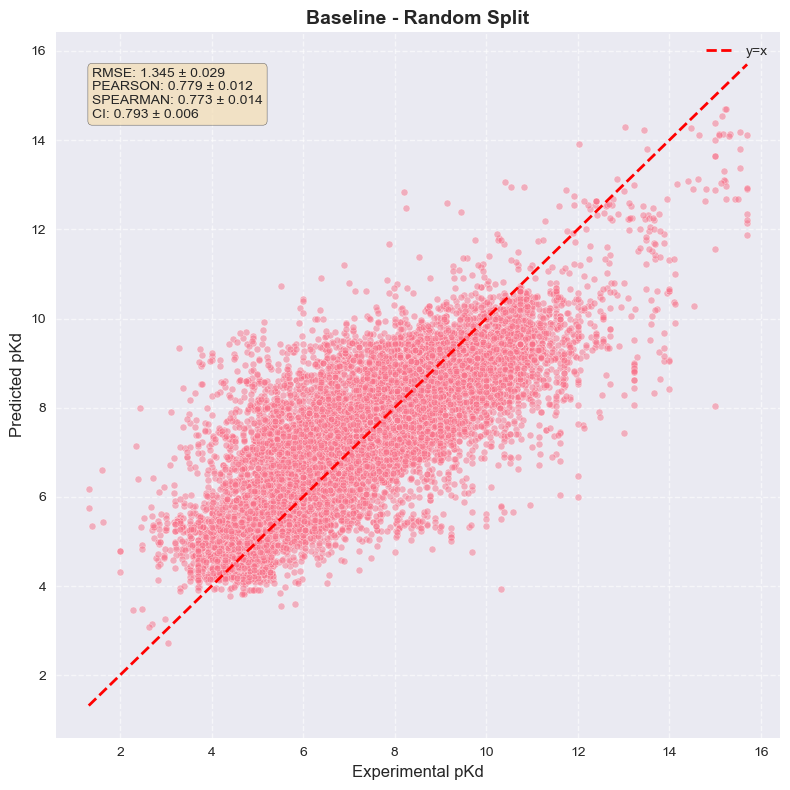

📊 Regression plot saved: fast_baseline_results_final\regression_random.png

⚡ Running 5-fold CV with 'cold_target' split
🔄 Creating cold_target splits with 5 folds
🔧 Initializing FastEmbeddingExtractor on cuda
📥 Loading ESM-2 model...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded. Using CLS token: <cls>
📥 Loaded 13879 cached embeddings from embedding_cache\embedding_cache.pkl
💾 Saved 13879 cached embeddings to embedding_cache\embedding_cache.pkl

==================== FOLD 1/5 ====================
   Split: Train=9615, Test=2404


Fold 1 Training:  57%|█████▋    | 17/30 [03:44<02:51, 13.21s/it, Train Loss=1.9116, Val RMSE=1.7175]


   ⏳ Early stopping at epoch 18. Val RMSE has not improved for 15 epochs.
   📊 Fold Results: RMSE: 1.6443, PEARSON: 0.6509, SPEARMAN: 0.6509, CI: 0.7321

==================== FOLD 2/5 ====================
   Split: Train=9615, Test=2404


...

   ⏳ Early stopping at epoch 23. Val RMSE has not improved for 15 epochs.
   📊 Fold Results: RMSE: 1.7468, PEARSON: 0.6092, SPEARMAN: 0.5654, CI: 0.6988

==================== FOLD 4/5 ====================
   Split: Train=9615, Test=2404


Fold 4 Training:  97%|█████████▋| 29/30 [06:12<00:12, 12.85s/it, Train Loss=1.7435, Val RMSE=1.5795]


   ⏳ Early stopping at epoch 30. Val RMSE has not improved for 15 epochs.
   📊 Fold Results: RMSE: 1.5196, PEARSON: 0.6583, SPEARMAN: 0.6502, CI: 0.7340

==================== FOLD 5/5 ====================
   Split: Train=9616, Test=2403


Fold 5 Training: 100%|██████████| 30/30 [06:11<00:00, 12.37s/it, Train Loss=1.6918, Val RMSE=1.7025]


   📊 Fold Results: RMSE: 1.6549, PEARSON: 0.6484, SPEARMAN: 0.6245, CI: 0.7259

📈 CV Summary (cold_target)
   RMSE: 1.6315 ± 0.0838
   PEARSON: 0.6503 ± 0.0272
   SPEARMAN: 0.6341 ± 0.0430
   CI: 0.7280 ± 0.0184


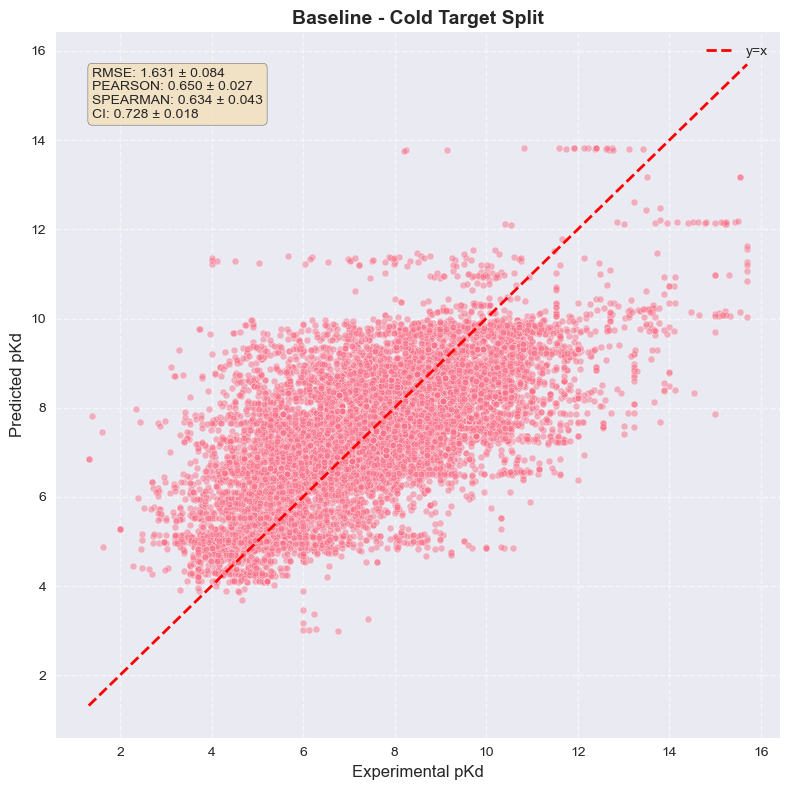

📊 Regression plot saved: fast_baseline_results_final\regression_cold_target.png

⚡ Running 5-fold CV with 'sequence_similarity' split
🔄 Creating sequence_similarity splits with 5 folds

🧬 Performing k-mer/agglomerative sequence similarity splitting...
   Found 11598 unique, sorted sequences.


Calculating similarities: 100%|██████████| 11598/11598 [36:32<00:00,  5.29it/s] 


🔧 Initializing FastEmbeddingExtractor on cuda
📥 Loading ESM-2 model...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded. Using CLS token: <cls>
📥 Loaded 13879 cached embeddings from embedding_cache\embedding_cache.pkl
💾 Saved 13879 cached embeddings to embedding_cache\embedding_cache.pkl

==================== FOLD 1/5 ====================
   Split: Train=8904, Test=3115


IndexError: positional indexers are out-of-bounds

In [ ]:


# ============================================================================
# 9. MAIN EXECUTION
# ============================================================================
def main():
    if not os.path.exists(r"C:\Users\hs494\PPIBALM\BALM-PPI\scripts\notebooks\PPB_Affinity_Sequences_Final (version 1).csv"): print("❌ Data.csv not found."); return

    config = {
        "epochs": 30, "batch_size": 1, "learning_rate": 1e-4, "patience": 15,
        "n_folds": 5, "seed": 42,
        "split_methods": ["random", "cold_target", "sequence_similarity"],
        "output_dir": "fast_baseline_results_final", "cache_dir": "embedding_cache"
    }

    print("\n⚙️ Baseline Configuration (from PEFT Scripts):")
    for key, value in config.items(): print(f"   {key}: {value}")

    df = pd.read_csv(r"C:\Users\hs494\PPIBALM\BALM-PPI\scripts\notebooks\PPB_Affinity_Sequences_Final (version 1).csv")
    df.dropna(subset=['Target', 'proteina', 'Y', 'PDB'], inplace=True)
    for col in ['Target', 'proteina', 'PDB']: df[col] = df[col].astype(str)
    df['Y'] = pd.to_numeric(df['Y'], errors='coerce'); df.dropna(subset=['Y'], inplace=True)
    print(f"✅ Data loaded and cleaned: {len(df)} samples")

    all_results = {sm: run_fast_cross_validation(df.copy(), sm, config) for sm in config['split_methods']}

    print(f"\n{'='*80}\n🎉 EXPERIMENT COMPARISON SUMMARY\n{'='*80}")
    create_comparison_plots(all_results, Path(config["output_dir"]))
    print("\n🎉 All experiments completed successfully!")

if __name__ == "__main__":
    main()

🧬 Fast Baseline Model for Protein-Protein Binding Affinity Prediction
⚡ Optimized with Pre-computed Embeddings
🔧 MODIFIED: Consistent Training Logic & JSON Serialization Fix
🔒 Setting up reproducibility with seed 42
✅ Reproducibility setup complete

⚙️ Baseline Configuration (from PEFT Scripts):
   epochs: 30
   batch_size: 1
   learning_rate: 0.0001
   patience: 15
   n_folds: 5
   seed: 42
   split_methods: ['sequence_similarity']
   output_dir: fast_baseline_results_final
   cache_dir: embedding_cache
✅ Data loaded, cleaned, and index reset: 12019 samples

⚡ Running 5-fold CV with 'sequence_similarity' split
🔄 Creating sequence_similarity splits with 5 folds

🧬 Performing k-mer/agglomerative sequence similarity splitting...
   Step 1: Extracting unique sequences...
   Found 11598 unique, sorted sequences.
   Step 2: Computing k-mer similarity matrix...


Calculating similarities: 100%|██████████| 11598/11598 [16:31<00:00, 11.70it/s] 


   Step 3: Clustering sequences...
   Created 2678 clusters
   Step 4: Creating 5-fold splits...
   Fold 1: Train=6516, Test=5503
   Fold 2: Train=7503, Test=4516
   Fold 3: Train=7340, Test=4679
   Fold 4: Train=7331, Test=4688
   Fold 5: Train=9397, Test=2622
🔧 Initializing FastEmbeddingExtractor on cuda
📥 Loading ESM-2 model...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded. Using CLS token: <cls>
📥 Loaded 13879 cached embeddings from C:\Users\hs494\Downloads\embedding_cache.pkl
💾 Saved 13879 cached embeddings to C:\Users\hs494\Downloads\embedding_cache.pkl

==================== FOLD 1/5 ====================
   Split: Train=6516, Test=5503


...

   ⏳ Early stopping at epoch 23. Val RMSE has not improved for 15 epochs.
   📊 Fold Results: RMSE: 1.9865, PEARSON: 0.5275, SPEARMAN: 0.5419, CI: 0.6881

==================== FOLD 4/5 ====================
   Split: Train=7331, Test=4688


Fold 4 Training:  77%|███████▋  | 23/30 [09:27<02:52, 24.66s/it, Train Loss=1.9847, Val RMSE=1.6828]


   ⏳ Early stopping at epoch 24. Val RMSE has not improved for 15 epochs.
   📊 Fold Results: RMSE: 1.5714, PEARSON: 0.6768, SPEARMAN: 0.6704, CI: 0.7376

==================== FOLD 5/5 ====================
   Split: Train=9397, Test=2622


Fold 5 Training:  80%|████████  | 24/30 [09:26<02:21, 23.59s/it, Train Loss=1.8714, Val RMSE=1.7837]


   ⏳ Early stopping at epoch 25. Val RMSE has not improved for 15 epochs.
   📊 Fold Results: RMSE: 1.6571, PEARSON: 0.5366, SPEARMAN: 0.4906, CI: 0.6702

📈 CV Summary (sequence_similarity)
   RMSE: 1.7546 ± 0.1603
   PEARSON: 0.5551 ± 0.0973
   SPEARMAN: 0.5454 ± 0.1025
   CI: 0.6909 ± 0.0388


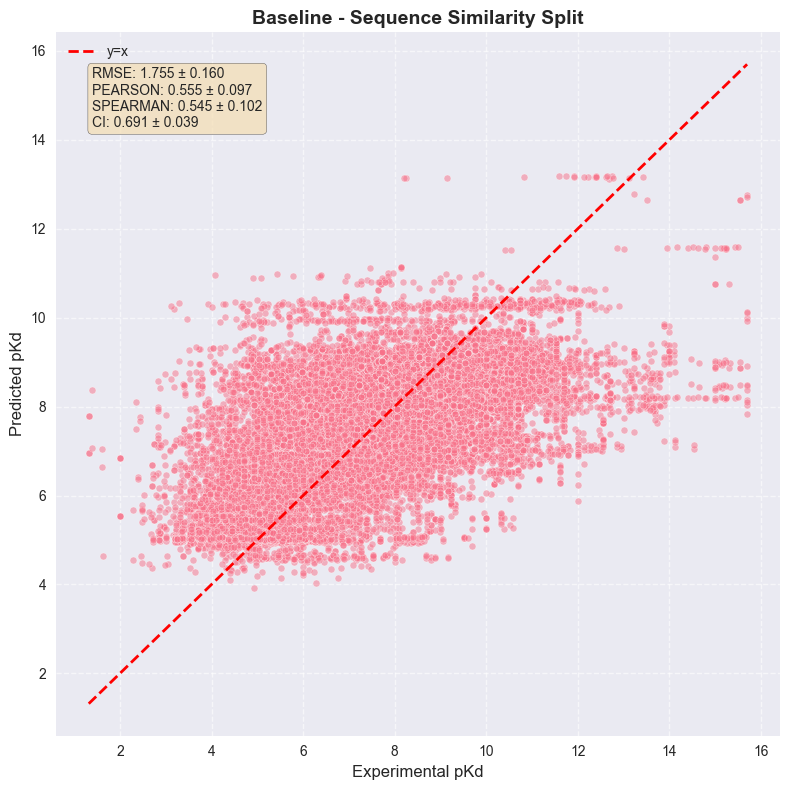

📊 Regression plot saved: fast_baseline_results_final\regression_sequence_similarity.png

🎉 EXPERIMENT COMPARISON SUMMARY
📊 Comparison plot saved: fast_baseline_results_final\comparison_metrics.png

🎉 All experiments completed successfully!


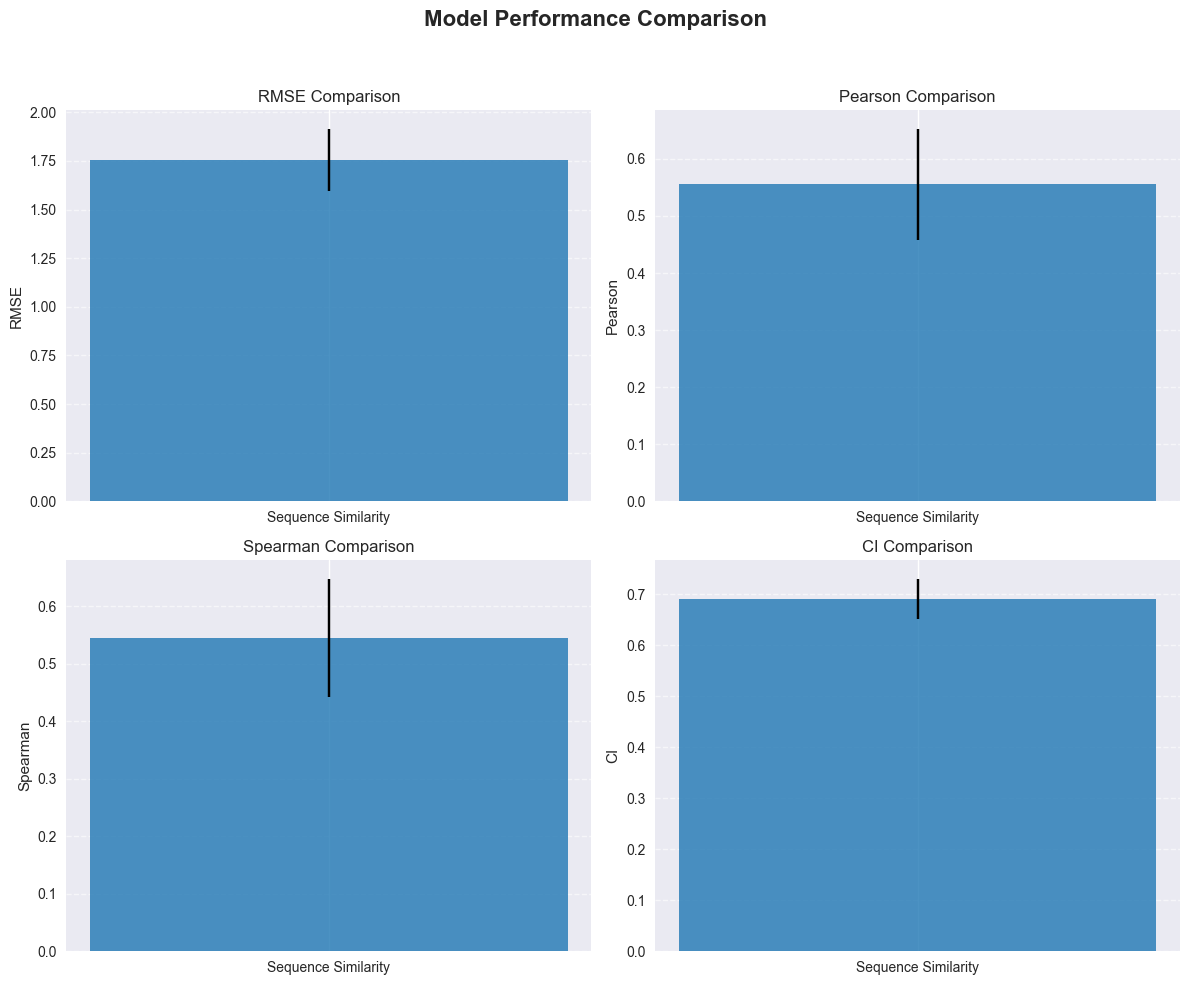

In [ ]:
# Fast Baseline Model for Protein-Protein Binding Affinity Prediction
# FINAL VERSION: Includes fix for JSON serialization of NumPy types.

import os
import sys
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import KFold, GroupKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import warnings
import pickle
import copy
from scipy.spatial.distance import squareform
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

# Imports for the sequence similarity split from PEFT script
from sklearn.cluster import AgglomerativeClustering

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🧬 Fast Baseline Model for Protein-Protein Binding Affinity Prediction")
print("⚡ Optimized with Pre-computed Embeddings")
print("🔧 MODIFIED: Consistent Training Logic & JSON Serialization Fix")
print("="*80)

# ============================================================================
# 1. REPRODUCIBILITY SETUP
# ============================================================================
def setup_reproducibility(seed=42):
    """Setup complete reproducibility."""
    print(f"🔒 Setting up reproducibility with seed {seed}")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Reproducibility setup complete")

setup_reproducibility(42)

# ============================================================================
# 2. FAST EMBEDDING COMPUTATION
# ============================================================================
class FastEmbeddingExtractor:
    def __init__(self, model_name="facebook/esm2_t33_650M_UR50D", max_seq_len=1024, batch_size=16, device="auto"):
        self.model_name, self.max_seq_len, self.batch_size = model_name, max_seq_len, batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if device == "auto" else torch.device(device)
        print(f"🔧 Initializing FastEmbeddingExtractor on {self.device}")
        print("📥 Loading ESM-2 model...")
        self.model = AutoModel.from_pretrained(model_name).to(self.device).eval()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Identify the CLS token (usually <s> for ESM-2)
        self.cls_token = self.tokenizer.cls_token
        self.embedding_size = self.model.config.hidden_size
        self.embedding_cache = {}
        print(f"✅ Model loaded. Using CLS token: {self.cls_token}")

    def get_embeddings(self, sequences, use_cache=True, show_progress=True):
        if isinstance(sequences, str): sequences = [sequences]
        embeddings, to_compute, to_compute_indices = [], [], []

        for i, seq in enumerate(sequences):
            if use_cache and seq in self.embedding_cache:
                embeddings.append(self.embedding_cache[seq])
            else:
                embeddings.append(None)
                to_compute.append(seq)
                to_compute_indices.append(i)

        if to_compute:
            if show_progress: print(f"🧮 Computing {len(to_compute)} new embeddings with Double CLS...")
            pbar = tqdm(range(0, len(to_compute), self.batch_size), desc="Computing embeddings", disable=not show_progress)

            for start_idx in pbar:
                batch_raw = to_compute[start_idx : start_idx + self.batch_size]

                # --- MODIFICATION: Replace '|' with '<s><s>' ---
                batch_sequences = [s.replace('|', f"{self.cls_token}{self.cls_token}") for s in batch_raw]

                inputs = self.tokenizer(batch_sequences, padding=True, truncation=True, max_length=self.max_seq_len, return_tensors="pt")
                inputs = {k: v.to(self.device) for k, v in inputs.items()}

                with torch.no_grad():
                    outputs = self.model(**inputs)
                    # Use Mean Pooling over last_hidden_state (more robust for concatenated chains)
                    hidden_states = outputs.last_hidden_state
                    attention_mask = inputs['attention_mask']

                    mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
                    sum_embeddings = torch.sum(hidden_states * mask_expanded, 1)
                    sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
                    batch_embeddings = (sum_embeddings / sum_mask).cpu()

                if use_cache:
                    for j, seq in enumerate(batch_raw):
                        self.embedding_cache[seq] = batch_embeddings[j:j+1]

                for i, orig_idx in enumerate(to_compute_indices[start_idx : start_idx + self.batch_size]):
                    embeddings[orig_idx] = batch_embeddings[i:i+1]

        return torch.cat(embeddings, dim=0)

    def save_cache(self, cache_path):
        with open(cache_path, 'wb') as f: pickle.dump(self.embedding_cache, f)
        print(f"💾 Saved {len(self.embedding_cache)} cached embeddings to {cache_path}")

    def load_cache(self, cache_path):
        if os.path.exists(cache_path):
            with open(cache_path, 'rb') as f: self.embedding_cache = pickle.load(f)
            print(f"📥 Loaded {len(self.embedding_cache)} cached embeddings from {cache_path}")

# ============================================================================
# 3. FAST BASELINE MODEL
# ============================================================================
class FastBaselinePPIModel(nn.Module):
    def __init__(self, embedding_size=1280, projected_size=256, projected_dropout=0.1, device="auto"):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if device == "auto" else torch.device(device)
        self.linear_projection = nn.Linear(2 * embedding_size, projected_size)
        self.dropout = nn.Dropout(projected_dropout)
        self.out = nn.Linear(projected_size, 1)
        self.loss_fn = nn.MSELoss()
        self.to(self.device)

    def forward(self, protein1_embeddings, protein2_embeddings, labels=None):
        concat_emb = torch.cat((protein1_embeddings.to(self.device), protein2_embeddings.to(self.device)), dim=1)
        proj_emb = F.relu(self.dropout(self.linear_projection(concat_emb)))
        logits = self.out(proj_emb).squeeze(-1)
        output = {"logits": logits}
        if labels is not None:
            output["loss"] = self.loss_fn(logits, labels.to(self.device))
        return output

# ============================================================================
# 4. DATASET & METRICS
# ============================================================================
class FastPPIDataset(Dataset):
    def __init__(self, dataframe, protein1_embeddings, protein2_embeddings):
        self.data, self.p1_emb, self.p2_emb = dataframe.reset_index(drop=True), protein1_embeddings, protein2_embeddings
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        return {"p1_emb": self.p1_emb[idx], "p2_emb": self.p2_emb[idx], "label": float(self.data.iloc[idx]["Y"])}

def fast_collate_fn(batch):
    return {
        "protein1_embeddings": torch.stack([item["p1_emb"] for item in batch]),
        "protein2_embeddings": torch.stack([item["p2_emb"] for item in batch]),
        "labels": torch.tensor([item["label"] for item in batch], dtype=torch.float32)
    }

def calculate_metrics(predictions, labels):
    predictions, labels = np.array(predictions), np.array(labels)
    # Return NaN if there are not enough samples for correlation metrics
    if len(labels) < 2: return {"rmse": np.nan, "pearson": np.nan, "spearman": np.nan, "ci": np.nan}
    rmse = np.sqrt(mean_squared_error(labels, predictions))
    pearson_r, _ = pearsonr(predictions, labels)
    spearman_r, _ = spearmanr(predictions, labels)
    def ci(y_true, y_pred):
        n, concordant = len(y_true), 0
        total_pairs = 0
        for i in range(n):
            for j in range(i + 1, n):
                if y_true[i] != y_true[j]:
                    total_pairs += 1
                    if (y_true[i] > y_true[j] and y_pred[i] > y_pred[j]) or \
                       (y_true[i] < y_true[j] and y_pred[i] < y_pred[j]):
                        concordant += 1
        return concordant / total_pairs if total_pairs > 0 else 1.0
    return {"rmse": rmse, "pearson": pearson_r, "spearman": spearman_r, "ci": ci(labels, predictions)}

# ============================================================================
# 5. TRAINING & EVALUATION LOOPS
# ============================================================================
def train_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        loss = model(**batch)["loss"]
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            all_preds.extend(model(**batch)["logits"].cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
    return all_preds, all_labels, calculate_metrics(all_preds, all_labels)

# ============================================================================
# 6. DATA SPLITTING (EXACT REPLICATION)
# ============================================================================
def _get_sequence_similarity_splits(df, n_folds=5, seed=42):
    print("\n🧬 Performing k-mer/agglomerative sequence similarity splitting...")
    
    # CRITICAL: Work with a clean copy and reset index
    df = df.reset_index(drop=True).copy()
    
    # Step 1: Extract unique sequences (SORTED for reproducibility)
    print("   Step 1: Extracting unique sequences...")
    sequence_columns = ['Target', 'proteina']
    all_sequences = set()
    sequence_to_records = {}
    
    for idx, row in df.iterrows():
        for col in sequence_columns:
            seq = str(row[col]).strip()  # MATCH PEFT: Use strip()
            if seq:
                all_sequences.add(seq)
                if seq not in sequence_to_records:
                    sequence_to_records[seq] = []
                sequence_to_records[seq].append(idx)
    
    # CRITICAL: Sort for reproducibility
    unique_sequences = sorted(list(all_sequences))
    print(f"   Found {len(unique_sequences)} unique, sorted sequences.")

    # Step 2: Compute k-mer similarity
    print("   Step 2: Computing k-mer similarity matrix...")
    def get_kmers(seq, k=3):
        if len(seq) < k:
            return {seq}
        return {seq[i:i+k] for i in range(len(seq) - k + 1)}
    
    kmer_sets = [get_kmers(s) for s in unique_sequences]
    sim_matrix = np.zeros((len(unique_sequences), len(unique_sequences)))
    
    for i in tqdm(range(len(unique_sequences)), desc="Calculating similarities"):
        for j in range(i, len(unique_sequences)):
            if i == j:
                sim_matrix[i, j] = 1.0
            else:
                inter = len(kmer_sets[i] & kmer_sets[j])
                union = len(kmer_sets[i] | kmer_sets[j])
                sim = inter / union if union > 0 else 0.0
                sim_matrix[i, j] = sim
                sim_matrix[j, i] = sim

    # Step 3: Cluster using scipy (DETERMINISTIC)
    print("   Step 3: Clustering sequences...")
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import linkage, fcluster

    distance_matrix = 1.0 - sim_matrix
    distance_threshold = 1.0 - 0.3  # threshold = 0.3

    condensed_dist = squareform(distance_matrix, checks=False)
    Z = linkage(condensed_dist, method='average')
    clusters = fcluster(Z, t=distance_threshold, criterion='distance')
    clusters = clusters - 1  # Convert to 0-indexed
    
    print(f"   Created {len(set(clusters))} clusters")

    # Step 4: Map sequences to clusters
    cluster_to_records = {}
    for seq_idx, cluster_id in enumerate(clusters):
        seq = unique_sequences[seq_idx]
        if cluster_id not in cluster_to_records:
            cluster_to_records[cluster_id] = []
        cluster_to_records[cluster_id].extend(sequence_to_records[seq])
    
    for cluster_id in cluster_to_records:
        cluster_to_records[cluster_id] = list(set(cluster_to_records[cluster_id]))

    # Step 5: K-Fold split on clusters
    print(f"   Step 4: Creating {n_folds}-fold splits...")
    cluster_ids = list(cluster_to_records.keys())
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    
    splits = []
    for fold_idx, (train_cluster_idx, test_cluster_idx) in enumerate(kf.split(cluster_ids)):
        train_clusters = set([cluster_ids[i] for i in train_cluster_idx])
        test_clusters = set([cluster_ids[i] for i in test_cluster_idx])
        
        # Create sequence-to-group mapping (MATCH PEFT EXACTLY)
        sequence_to_group = {}
        for seq_idx, cluster_id in enumerate(clusters):
            sequence = unique_sequences[seq_idx]
            if cluster_id in train_clusters:
                sequence_to_group[sequence] = 'train'
            elif cluster_id in test_clusters:
                sequence_to_group[sequence] = 'test'
        
        # Assign samples to train/test (MATCH PEFT EXACTLY)
        train_indices, test_indices = [], []
        
        for idx, row in df.iterrows():
            seq_target = str(row['Target']).strip()
            seq_proteina = str(row['proteina']).strip()
            
            cluster_target_id = sequence_to_group.get(seq_target)
            cluster_proteina_id = sequence_to_group.get(seq_proteina)
            
            # EXACT MATCH to PEFT logic
            if cluster_target_id == 'test' or cluster_proteina_id == 'test':
                test_indices.append(idx)
            else:
                train_indices.append(idx)
        
        train_idx = np.array(train_indices)
        test_idx = np.array(test_indices)
        
        print(f"   Fold {fold_idx + 1}: Train={len(train_idx)}, Test={len(test_idx)}")
        splits.append((train_idx, test_idx))
    
    return splits, df

def get_data_splits(df, split_method="random", n_folds=5, seed=42):
    print(f"🔄 Creating {split_method} splits with {n_folds} folds")
    if split_method == "random": return list(KFold(n_splits=n_folds, shuffle=True, random_state=seed).split(df)), df
    if split_method == "cold_target": return list(GroupKFold(n_splits=n_folds).split(df, groups=df["PDB"].factorize()[0])), df
    if split_method == "sequence_similarity": return _get_sequence_similarity_splits(df, n_folds, seed)
    raise ValueError(f"Unknown split method: {split_method}")

# ============================================================================
# 7. MAIN CROSS-VALIDATION FUNCTION (WITH JSON FIX)
# ============================================================================
def json_converter(o):
    """Helper function to convert numpy types to native python types for JSON serialization."""
    if isinstance(o, np.generic):
        return o.item() # .item() converts numpy types to python native types
    raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")

def run_fast_cross_validation(df, split_method, config):
    print(f"\n⚡ Running {config['n_folds']}-fold CV with '{split_method}' split")
    output_dir = Path(config["output_dir"]); cache_dir = Path(config["cache_dir"])
    output_dir.mkdir(exist_ok=True, parents=True); cache_dir.mkdir(exist_ok=True, parents=True)

    splits, df_processed = get_data_splits(df, split_method, config['n_folds'], config['seed'])

    embedding_extractor = FastEmbeddingExtractor()
    cache_file = Path("C:\\Users\\hs494\\Downloads\\embedding_cache.pkl")
    embedding_extractor.load_cache(cache_file)

    all_seqs = sorted(list(set(df_processed["Target"].tolist() + df_processed["proteina"].tolist())))
    unique_embs = embedding_extractor.get_embeddings(all_seqs)
    seq_to_emb = {seq: unique_embs[i:i+1] for i, seq in enumerate(all_seqs)}
    embedding_extractor.save_cache(cache_file)

    p1_embs = torch.cat([seq_to_emb[seq] for seq in df_processed["Target"]], dim=0)
    p2_embs = torch.cat([seq_to_emb[seq] for seq in df_processed["proteina"]], dim=0)

    cv_results, all_predictions, all_labels = [], [], []

    for fold, (train_idx, test_idx) in enumerate(splits):
        fold_num = fold + 1
        print(f"\n{'='*20} FOLD {fold_num}/{config['n_folds']} {'='*20}")
        print(f"   Split: Train={len(train_idx)}, Test={len(test_idx)}")

        train_loader = DataLoader(FastPPIDataset(df_processed.iloc[train_idx], p1_embs[train_idx], p2_embs[train_idx]),
                                  batch_size=config['batch_size'], shuffle=True, collate_fn=fast_collate_fn)
        test_loader = DataLoader(FastPPIDataset(df_processed.iloc[test_idx], p1_embs[test_idx], p2_embs[test_idx]),
                                 batch_size=config['batch_size']*2, shuffle=False, collate_fn=fast_collate_fn)

        model = FastBaselinePPIModel()
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])

        best_val_rmse, patience_counter, best_model_state = float('inf'), 0, None

        pbar = tqdm(range(config['epochs']), desc=f"Fold {fold_num} Training")
        for epoch in pbar:
            train_loss = train_epoch(model, train_loader, optimizer)
            
            # Evaluate on validation set
            _, _, val_metrics = evaluate_model(model, test_loader)
            current_val_rmse = val_metrics['rmse']
            
            pbar.set_postfix({
                "Train Loss": f"{train_loss:.4f}", 
                "Val RMSE": f"{current_val_rmse:.4f}"
            })

            # Save best model based on Validation RMSE (consistent with PEFT)
            if current_val_rmse < best_val_rmse:
                best_val_rmse = current_val_rmse
                patience_counter = 0
                best_model_state = copy.deepcopy(model.state_dict())
                # print(f"   -> New best model with Val RMSE: {best_val_rmse:.4f}")
            else:
                patience_counter += 1

            if patience_counter >= config['patience']:
                print(f"   ⏳ Early stopping at epoch {epoch+1}. Val RMSE has not improved for {config['patience']} epochs.")
                break

        if best_model_state: model.load_state_dict(best_model_state)

        preds, labels, metrics = evaluate_model(model, test_loader)
        cv_results.append(metrics); all_predictions.extend(preds); all_labels.extend(labels)
        print(f"   📊 Fold Results: " + ", ".join([f"{k.upper()}: {v:.4f}" for k, v in metrics.items()]))
        del model; torch.cuda.empty_cache()

    print(f"\n📈 CV Summary ({split_method})")
    summary_df = pd.DataFrame(cv_results)
    aggregate_metrics = {f"{key}_{stat}": summary_df[key].agg(stat) for key in summary_df.columns for stat in ['mean', 'std']}
    for key in summary_df.columns:
        print(f"   {key.upper()}: {aggregate_metrics[f'{key}_mean']:.4f} ± {aggregate_metrics[f'{key}_std']:.4f}")

    create_regression_plot(all_predictions, all_labels, aggregate_metrics, output_dir / f"regression_{split_method}.png",
                           f"Baseline - {split_method.replace('_', ' ').title()} Split")

    results = {"split_method": split_method, "aggregate_metrics": aggregate_metrics}
    # MODIFIED: Use the default converter to handle numpy types
    with open(output_dir / f"results_{split_method}.json", 'w') as f:
        json.dump(results, f, indent=2, default=json_converter)
    return results

# ============================================================================
# 8. PLOTTING
# ============================================================================
def create_regression_plot(preds, labels, metrics, save_path, title):
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=labels, y=preds, alpha=0.5, s=25)
    min_max = [min(min(labels), min(preds)), max(max(labels), max(preds))]
    plt.plot(min_max, min_max, 'r--', lw=2, label='y=x')
    plt.xlabel("Experimental pKd", fontsize=12); plt.ylabel("Predicted pKd", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    text = "\n".join([f"{k.replace('_mean','').upper()}: {metrics[k]:.3f} ± {metrics[k.replace('mean','std')]:.3f}" for k in metrics if 'mean' in k])
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
    plt.grid(True, linestyle='--', alpha=0.6); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()
    print(f"📊 Regression plot saved: {save_path}")

def create_comparison_plots(all_results, output_dir):
    df_data = [{"Split": sm.replace('_', ' ').title(), "Metric": metric, "Mean": res["aggregate_metrics"][f'{metric.lower()}_mean'], "Std": res["aggregate_metrics"][f'{metric.lower()}_std']}
               for sm, res in all_results.items() for metric in ["RMSE", "Pearson", "Spearman", "CI"]]
    plot_df = pd.DataFrame(df_data)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    for ax, metric in zip(axes.flatten(), ["RMSE", "Pearson", "Spearman", "CI"]):
        subset = plot_df[plot_df['Metric'] == metric]
        ax.bar(subset['Split'], subset['Mean'], yerr=subset['Std'], capsize=5, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax.set_title(f'{metric} Comparison'); ax.set_ylabel(metric)
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_dir / "comparison_metrics.png", dpi=300)
    print(f"📊 Comparison plot saved: {output_dir / 'comparison_metrics.png'}")

# ============================================================================
# 9. MAIN EXECUTION
# ============================================================================
def main():
    if not os.path.exists(r"D:\BALM_Fineclone\BALM-PPI\scripts\notebooks\PPB_Affinity_Sequences_Final (version 1).csv"): print("❌ Data.csv not found."); return

    config = {
        "epochs": 30, "batch_size": 1, "learning_rate": 1e-4, "patience": 15,
        "n_folds": 5, "seed": 42,
        "split_methods": ["sequence_similarity"],
        "output_dir": "fast_baseline_results_final", "cache_dir": "embedding_cache"
    }

    print("\n⚙️ Baseline Configuration (from PEFT Scripts):")
    for key, value in config.items(): print(f"   {key}: {value}")

    df = pd.read_csv(r"D:\BALM_Fineclone\BALM-PPI\scripts\notebooks\PPB_Affinity_Sequences_Final (version 1).csv")
    df.dropna(subset=['Target', 'proteina', 'Y', 'PDB'], inplace=True)
    for col in ['Target', 'proteina', 'PDB']: df[col] = df[col].astype(str)
    df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
    df.dropna(subset=['Y'], inplace=True)
    
    # CRITICAL FIX: Reset index so index labels match positional integer indices (0 to N-1)
    df = df.reset_index(drop=True) 
    
    print(f"✅ Data loaded, cleaned, and index reset: {len(df)} samples")


    all_results = {sm: run_fast_cross_validation(df.copy(), sm, config) for sm in config['split_methods']}

    print(f"\n{'='*80}\n🎉 EXPERIMENT COMPARISON SUMMARY\n{'='*80}")
    create_comparison_plots(all_results, Path(config["output_dir"]))
    print("\n🎉 All experiments completed successfully!")

if __name__ == "__main__":
    main()